In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('customer.csv')

In [3]:
df.head()

,Cust_Number,Yearly_Income,Age,Cust_Spend_Score,Sex
0,CUSTID1,15000,18,44,0
1,CUSTID2,15000,18,79,0
2,CUSTID3,16000,23,8,1
3,CUSTID4,16000,25,79,1
4,CUSTID5,17000,32,41,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Cust_Number       200 non-null    object
 1   Yearly_Income     200 non-null    int64 
 2   Age               200 non-null    int64 
 3   Cust_Spend_Score  200 non-null    int64 
 4   Sex               200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Drop un-necessary variables
df = df.drop(['Cust_Number','Sex'], axis=1)

In [6]:
df.head()

,Yearly_Income,Age,Cust_Spend_Score
0,15000,18,44
1,15000,18,79
2,16000,23,8
3,16000,25,79
4,17000,32,41


In [7]:
df.describe()

,Yearly_Income,Age,Cust_Spend_Score
count,200.000000,200.000000,200.000000
mean,60560.000000,39.095000,51.380000
std,26264.721165,14.088592,26.034488
min,15000.000000,17.000000,1.000000
25%,41500.000000,28.000000,33.750000
50%,61500.000000,36.000000,51.000000
75%,78000.000000,49.250000,72.000000
max,137000.000000,73.000000,103.000000


<Axes: >

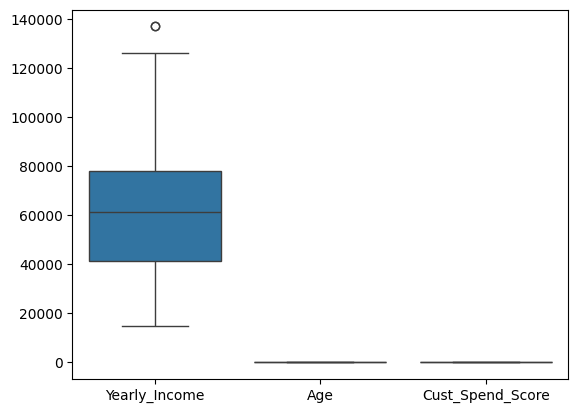

In [8]:
# Checking for outliers 
sns.boxplot(data=df)

In [9]:
# As the Yearly_income has higher values compared to other variables, therefore we need to scale them at same level. 

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

In [22]:
X = pd.DataFrame(df_scaled, columns = df.columns)

<Axes: >

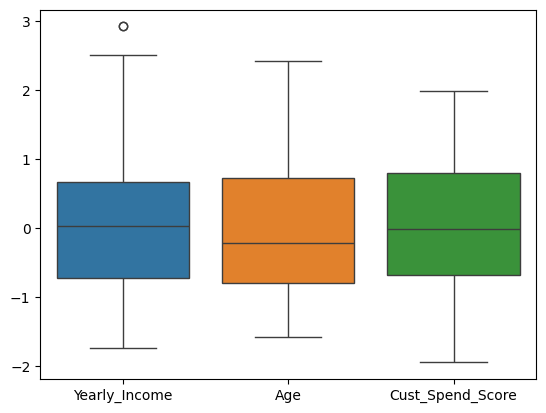

In [24]:
sns.boxplot(data=X)

In [12]:
# Now the values look on similar scale for all variables.
# There is an outlier in the Column Yearly_Income, which needs to be treated

In [30]:
Q1,Q3 = np.percentile(X,[25,75])
IQR = Q3-Q1

ur = Q3+(1.5*IQR)
lr = Q1-(1.5*IQR)

X['Yearly_Income'] = np.where(X['Yearly_Income']>ur, ur, X['Yearly_Income'])
X['Yearly_Income'] = np.where(X['Yearly_Income']<lr, lr, X['Yearly_Income'])

<Axes: >

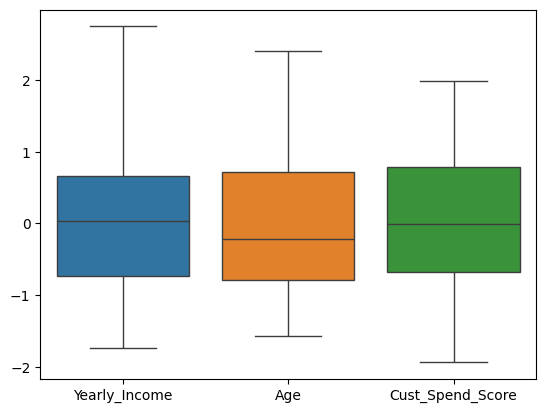

In [32]:
# Post Outlier Treament
sns.boxplot(data=X)

In [34]:
# Applying Clustering
from sklearn.cluster import KMeans

# Finding WCSS
wcss= []

for i in range(1,21):
    kmeans = KMeans(n_clusters = i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

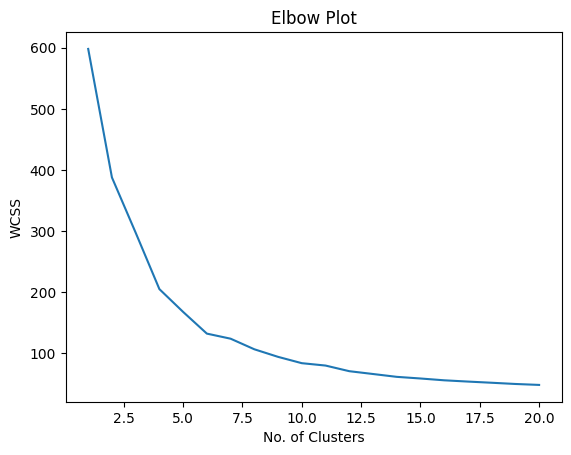

In [38]:
plt.plot(range(1,21), wcss)

plt.title("Elbow Plot")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")

Text(0, 0.5, 'WCSS')

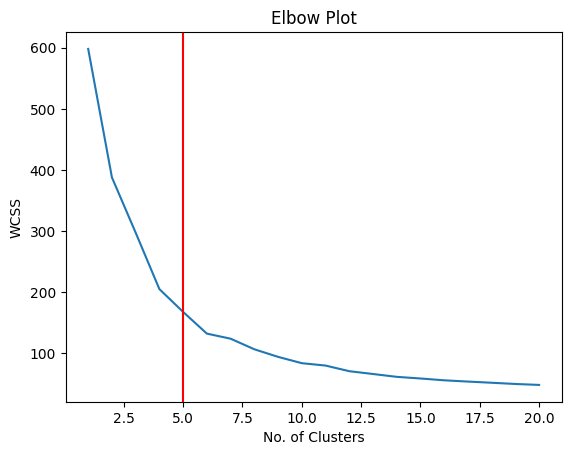

In [40]:
plt.plot(range(1,21), wcss)

plt.axvline(x = 5, color = 'red') ####
plt.title("Elbow Plot")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")

In [45]:
# Optimal value of K Silhouette Score 
from sklearn.metrics import silhouette_score
n_clusters = [2,3,4,5]

for K in n_clusters:
    cluster = KMeans(n_clusters=K, random_state=42)
    predict = cluster.fit_predict(X)
    score = silhouette_score(X, predict, random_state=42)
    print ("For {} clusters the silhouette score is {})".format(K, score))

For 2 clusters the silhouette score is 0.3327893015569819)
For 3 clusters the silhouette score is 0.34710275199282736)
For 4 clusters the silhouette score is 0.4016908466990142)
For 5 clusters the silhouette score is 0.4065949784077965)
